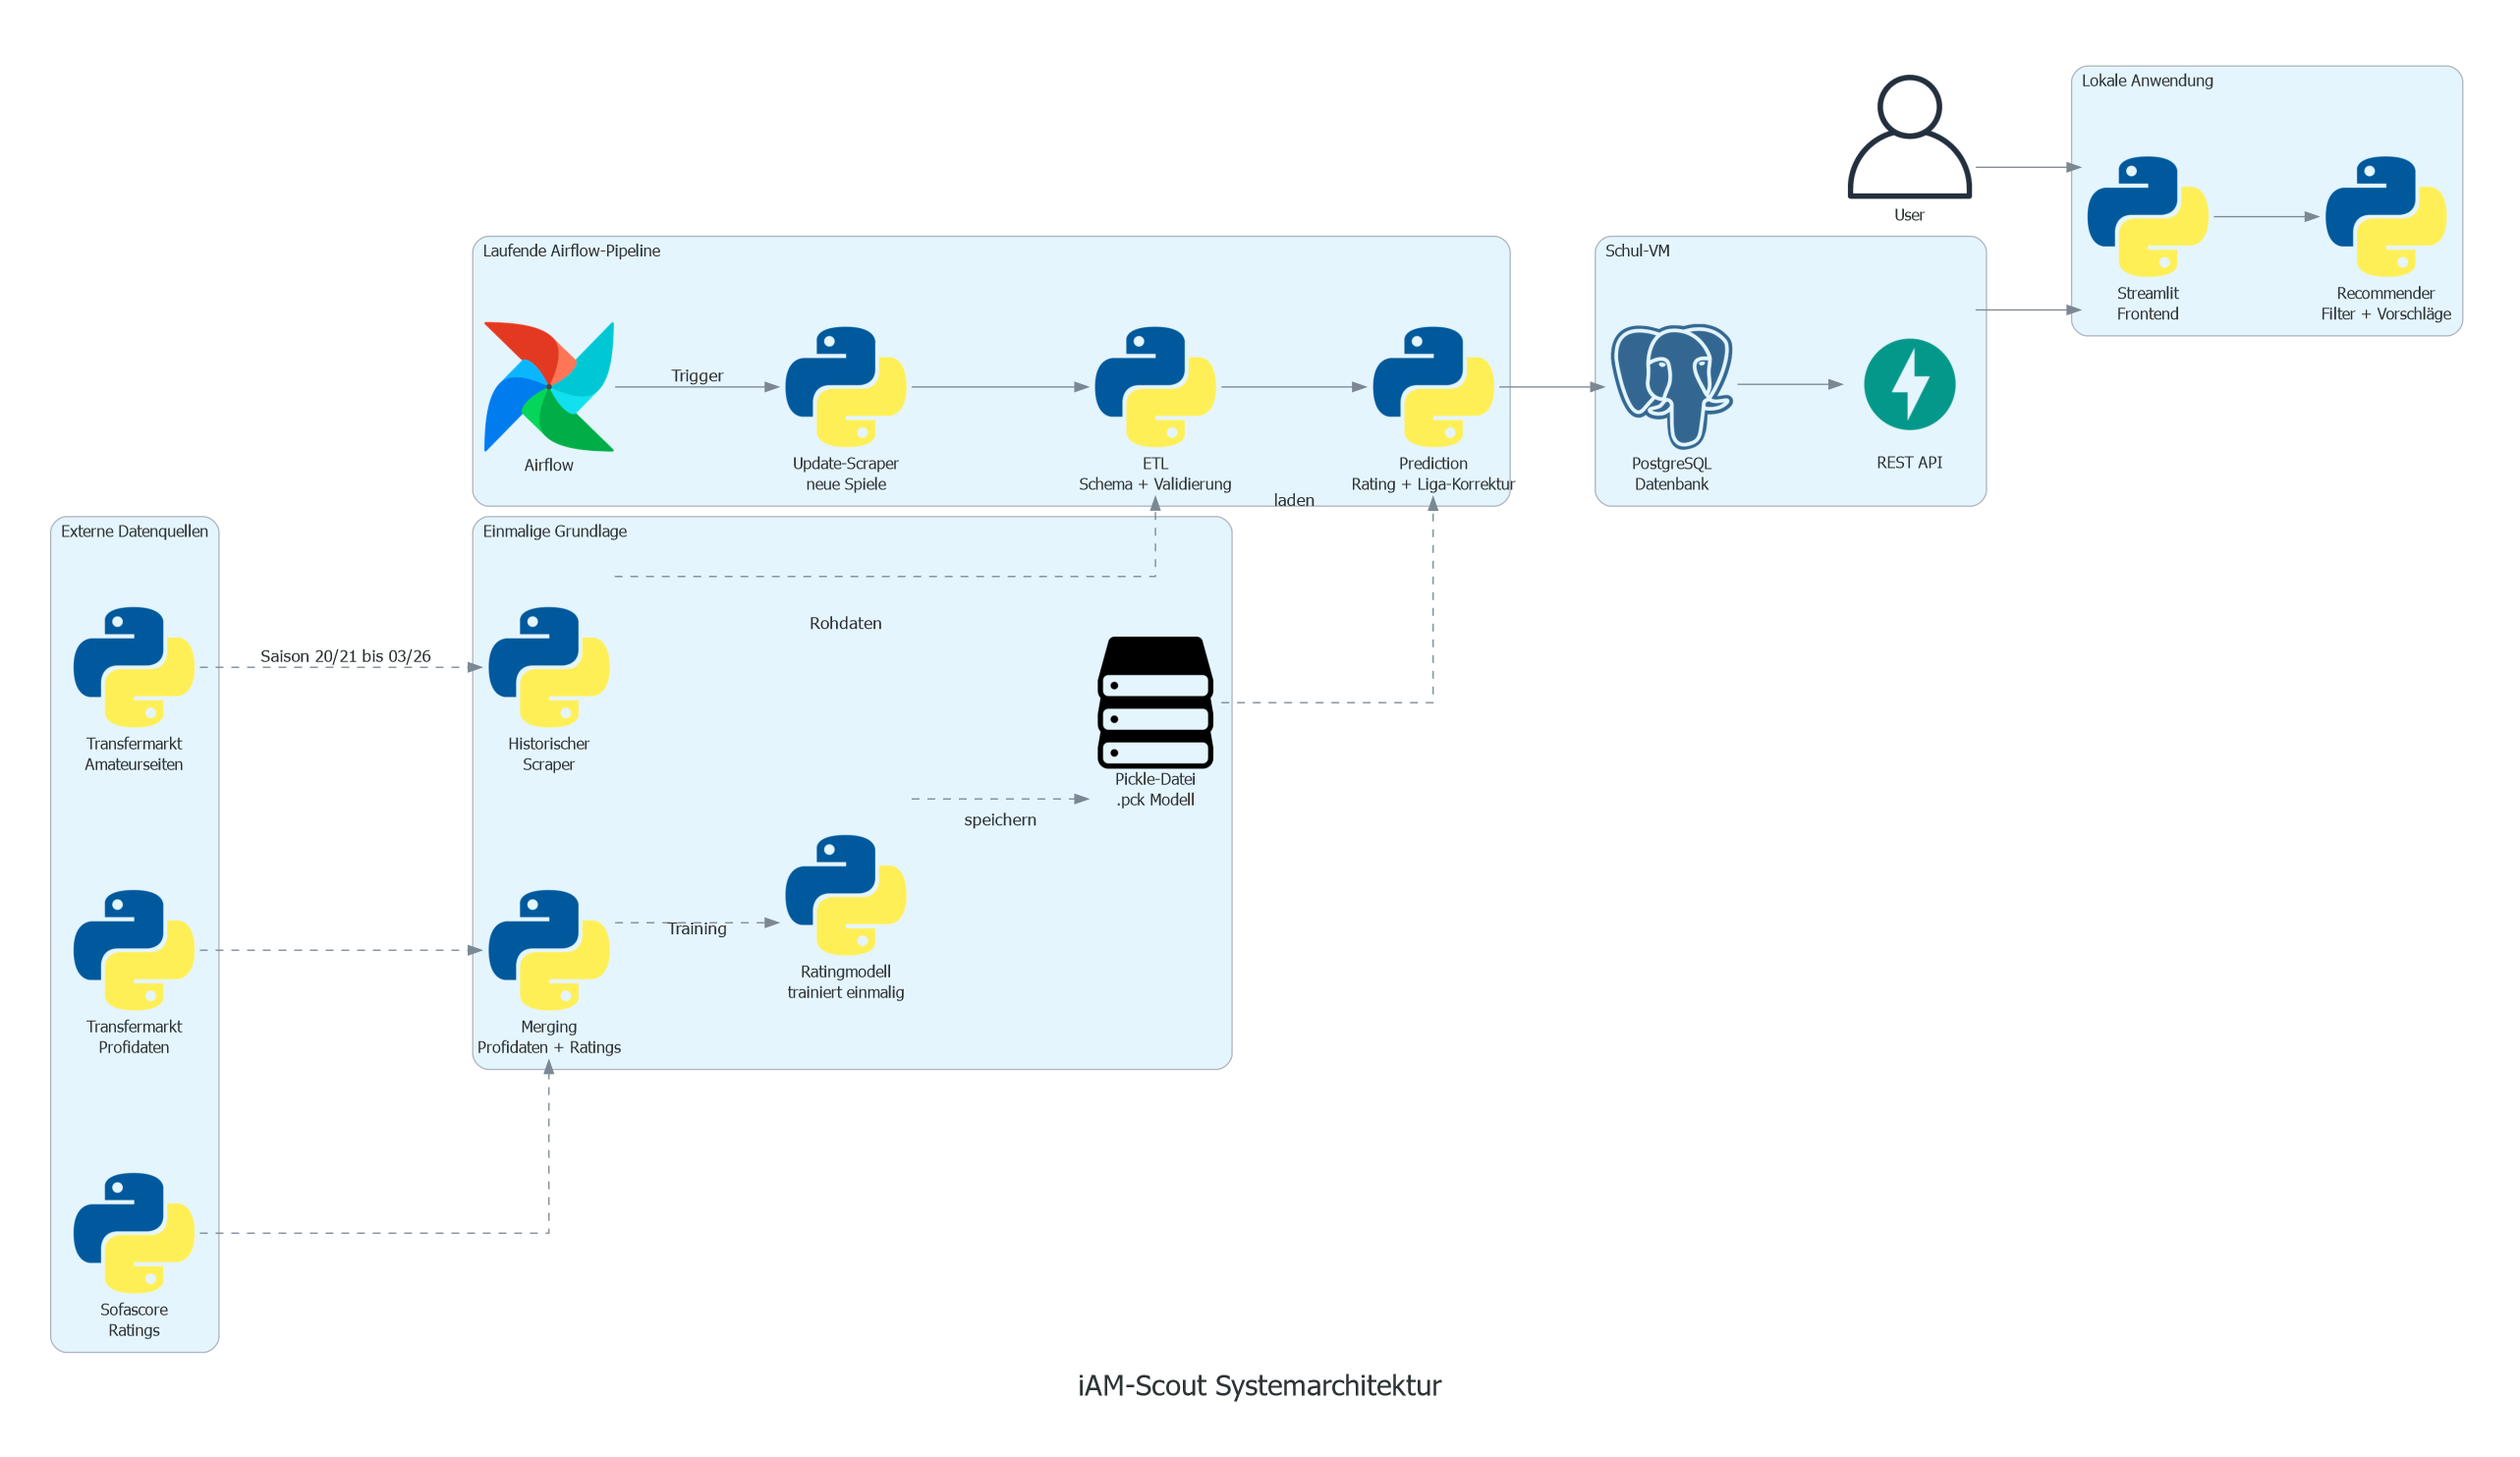

In [7]:
from tempfile import TemporaryDirectory
from IPython.display import Image, display

from diagrams import Diagram, Cluster, Edge
from diagrams.onprem.workflow import Airflow
from diagrams.onprem.database import PostgreSQL
from diagrams.onprem.client import User
from diagrams.programming.language import Python
from diagrams.programming.framework import FastAPI
from diagrams.generic.storage import Storage


with TemporaryDirectory() as tmpdir:
    filename = f"{tmpdir}/iam_scout_architektur"

    with Diagram(
        "iAM-Scout Systemarchitektur",
        filename=filename,
        show=False,
        direction="LR",
        outformat="png",
        graph_attr={
            "fontsize": "22",
            "bgcolor": "white",
            "pad": "0.5",
            "ranksep": "1.1",
            "nodesep": "0.7"
        },
        node_attr={
            "fontsize": "12"
        },
        edge_attr={
            "fontsize": "10"
        }
    ):

        user = User("User")

        with Cluster("Externe Datenquellen"):
            tm_amateur_pages = Python("Transfermarkt\nAmateurseiten")
            tm_pro = Python("Transfermarkt\nProfidaten")
            sofascore = Python("Sofascore\nRatings")

        with Cluster("Einmalige Grundlage"):
            historical_scraper = Python("Historischer\nScraper")
            merge = Python("Merging\nProfidaten + Ratings")
            model = Python("Ratingmodell\ntrainiert einmalig")
            model_file = Storage("Pickle-Datei\n.pck Modell")

        with Cluster("Laufende Airflow-Pipeline"):
            airflow = Airflow("Airflow")
            update_scraper = Python("Update-Scraper\nneue Spiele")
            etl = Python("ETL\nSchema + Validierung")
            prediction = Python("Prediction\nRating + Liga-Korrektur")

        with Cluster("Schul-VM"):
            db = PostgreSQL("PostgreSQL\nDatenbank")
            api = FastAPI("REST API")

        with Cluster("Lokale Anwendung"):
            frontend = Python("Streamlit\nFrontend")
            recommender = Python("Recommender\nFilter + Vorschläge")

        # Einmaliger historischer Import
        tm_amateur_pages >> Edge(label="Saison 20/21 bis 03/26", style="dashed") >> historical_scraper
        historical_scraper >> Edge(label="Rohdaten", style="dashed") >> etl

        # Einmaliges Modelltraining
        tm_pro >> Edge(style="dashed") >> merge
        sofascore >> Edge(style="dashed") >> merge
        merge >> Edge(label="Training", style="dashed") >> model
        model >> Edge(label="speichern", style="dashed") >> model_file

        # Laufende Pipeline
        airflow >> Edge(label="Trigger") >> update_scraper
        update_scraper >> etl
        etl >> prediction
        model_file >> Edge(label="laden", style="dashed") >> prediction
        prediction >> db

        # Anwendung
        db >> api
        api >> frontend
        frontend >> recommender
        user >> frontend

    display(Image(filename=f"{filename}.png"))

In [ ]:
import pandas as pd

# Load the pro stats data
df = pd.read_csv("../data/data/transform/pro/stats_with_rating.csv")

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\n" + "="*50)
print("Top 10 matches by player appearances:")
print("="*50)

# Group by match_id and count player appearances
if 'match_id' in df.columns:
    match_counts = df.groupby('match_id').size().sort_values(ascending=False).head(10)
    print(match_counts)
    print("\nMatch details:")
    for match_id in match_counts.index[:10]:
        match_data = df[df['match_id'] == match_id].iloc[0]
        print(f"\nMatch ID: {match_id}")
        print(f"  Players in dataset: {match_counts[match_id]}")
        if 'game_date' in df.columns:
            print(f"  Date: {match_data['game_date']}")
else:
    print("No 'match_id' column found. Available columns:")
    print(df.columns.tolist())